# Импорт библиотек и генерация данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = (14, 6)

# Файлы перепутаны местами, используем наоборот
TRAIN_PATH = '../data/raw/UNSW_NB15/UNSW_NB15_testing-set.csv' 
TEST_PATH = '../data/raw/UNSW_NB15/UNSW_NB15_training-set.csv' 

print(f"\nЗагрузка training set...")
df_train = pd.read_csv(TRAIN_PATH)
print(f"Training set: {len(df_train):,} записей")

print(f"\nЗагрузка test set...")
df_test = pd.read_csv(TEST_PATH)
print(f"Test set: {len(df_test):,} записей")

print(f"\nИтого: {len(df_train) + len(df_test):,} записей")

df = df_train.copy()
print(f"\nEDA выполняется на training set ({len(df):,} записей)")


Загрузка training set...
Training set: 175,341 записей

Загрузка test set...
Test set: 82,332 записей

Итого: 257,673 записей

EDA выполняется на training set (175,341 записей)


# Первичный осмотр данных

In [2]:
print(f"Размер: {df.shape}")
print(f"Колонки: {len(df.columns)}")
print(f"Пропуски: {df.isnull().sum().sum()}")

print("\nПервые 5 строк:")
display(df.head())

print("\nСтатистика:")
display(df.describe())

Размер: (175341, 45)
Колонки: 45
Пропуски: 0

Первые 5 строк:


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0



Статистика:


,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


#  Анализ целевой переменной (аномалии)


Распределение классов:
  Normal (0):   56,000 ( 31.9%)
  Attack (1):  119,341 ( 68.1%)


C:\Users\danya\AppData\Local\Temp\ipykernel_11028\524763596.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values,


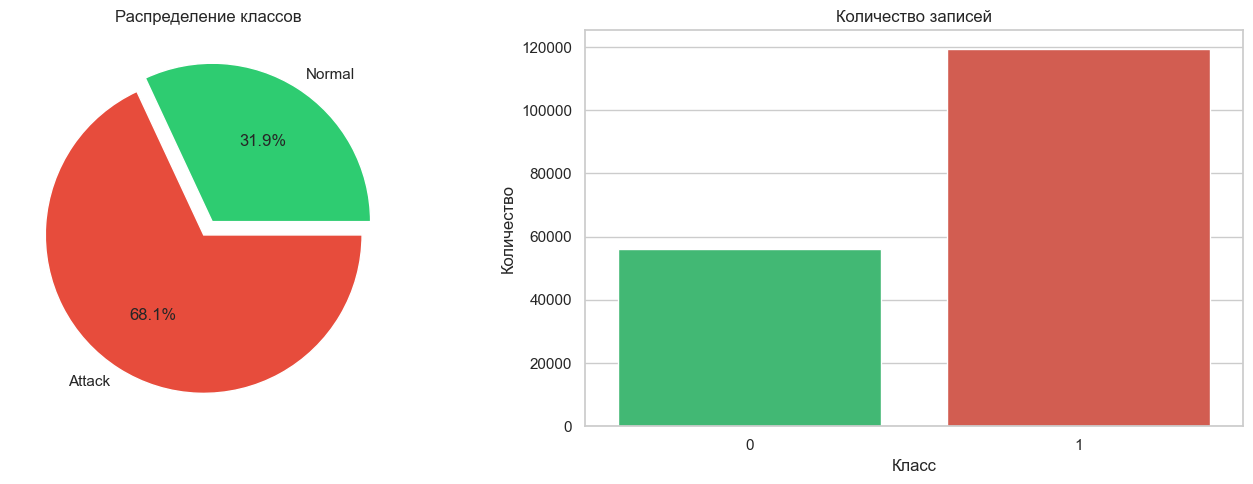

Сохранено: 01_class_distribution.png


In [3]:
label_counts = df['label'].value_counts()
label_pct = df['label'].value_counts(normalize=True) * 100

print(f"\nРаспределение классов:")
print(f"  Normal (0): {label_counts.get(0, 0):>8,} ({label_pct.get(0, 0):>5.1f}%)")
print(f"  Attack (1): {label_counts.get(1, 0):>8,} ({label_pct.get(1, 0):>5.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie([label_pct.get(0, 0), label_pct.get(1, 0)], 
            labels=['Normal', 'Attack'], 
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            explode=(0.05, 0.05))
axes[0].set_title('Распределение классов')

sns.barplot(x=label_counts.index, y=label_counts.values, 
            ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Количество записей')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.savefig('../artifacts/visualizations/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Сохранено: 01_class_distribution.png")

# Анализ типов атак


Всего типов атак: 9

Топ-10 типов атак:
   1. Generic                     40,000 ( 33.5%)
   2. Exploits                    33,393 ( 28.0%)
   3. Fuzzers                     18,184 ( 15.2%)
   4. DoS                         12,264 ( 10.3%)
   5. Reconnaissance              10,491 (  8.8%)
   6. Analysis                     2,000 (  1.7%)
   7. Backdoor                     1,746 (  1.5%)
   8. Shellcode                    1,133 (  0.9%)
   9. Worms                          130 (  0.1%)


C:\Users\danya\AppData\Local\Temp\ipykernel_11028\426607121.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Reds_r')


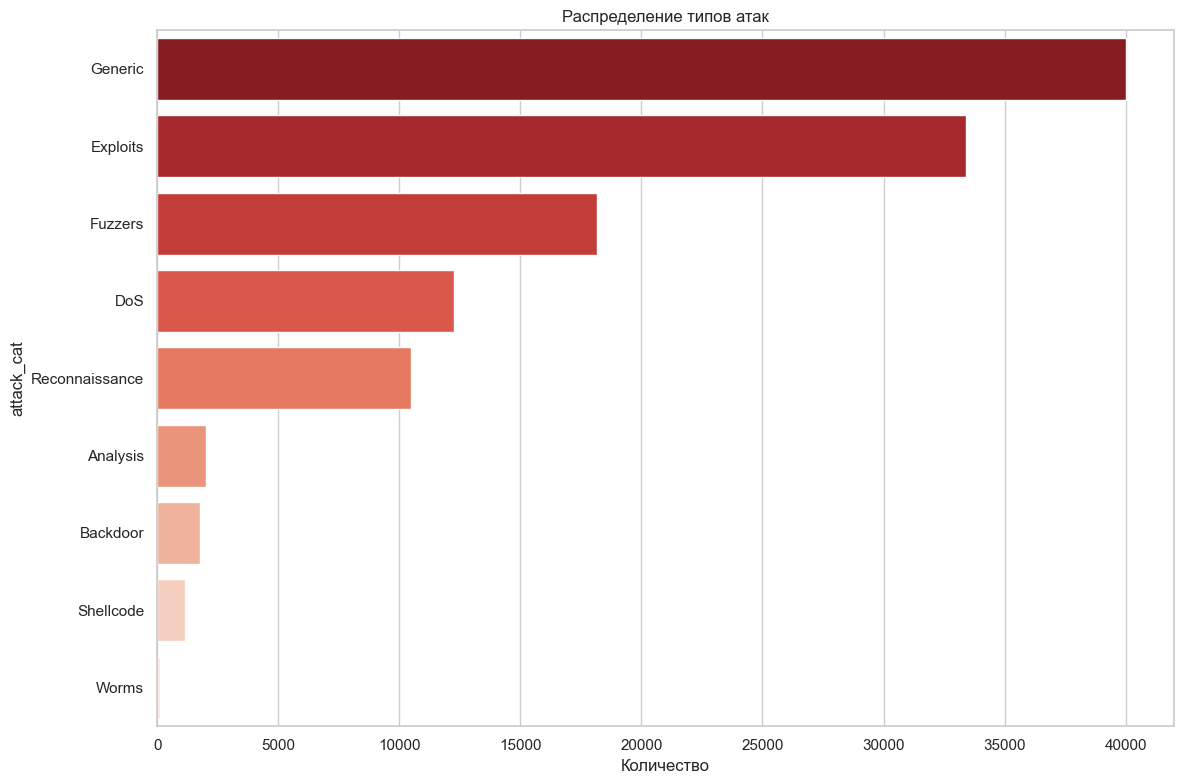

Сохранено: 02_attack_types.png


In [4]:
attacks_df = df[df['label'] == 1].copy()
attack_counts = attacks_df['attack_cat'].value_counts()

print(f"\nВсего типов атак: {len(attack_counts)}")
print("\nТоп-10 типов атак:")
for i, (attack, count) in enumerate(attack_counts.head(10).items(), 1):
    pct = count / len(attacks_df) * 100
    print(f"  {i:2d}. {attack:<25} {count:>8,} ({pct:>5.1f}%)")

plt.figure(figsize=(12, 8))
sns.barplot(x=attack_counts.values, y=attack_counts.index, palette='Reds_r')
plt.title('Распределение типов атак')
plt.xlabel('Количество')
plt.tight_layout()
plt.savefig('../artifacts/visualizations/02_attack_types.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 02_attack_types.png")


# Анализ метрик трафика

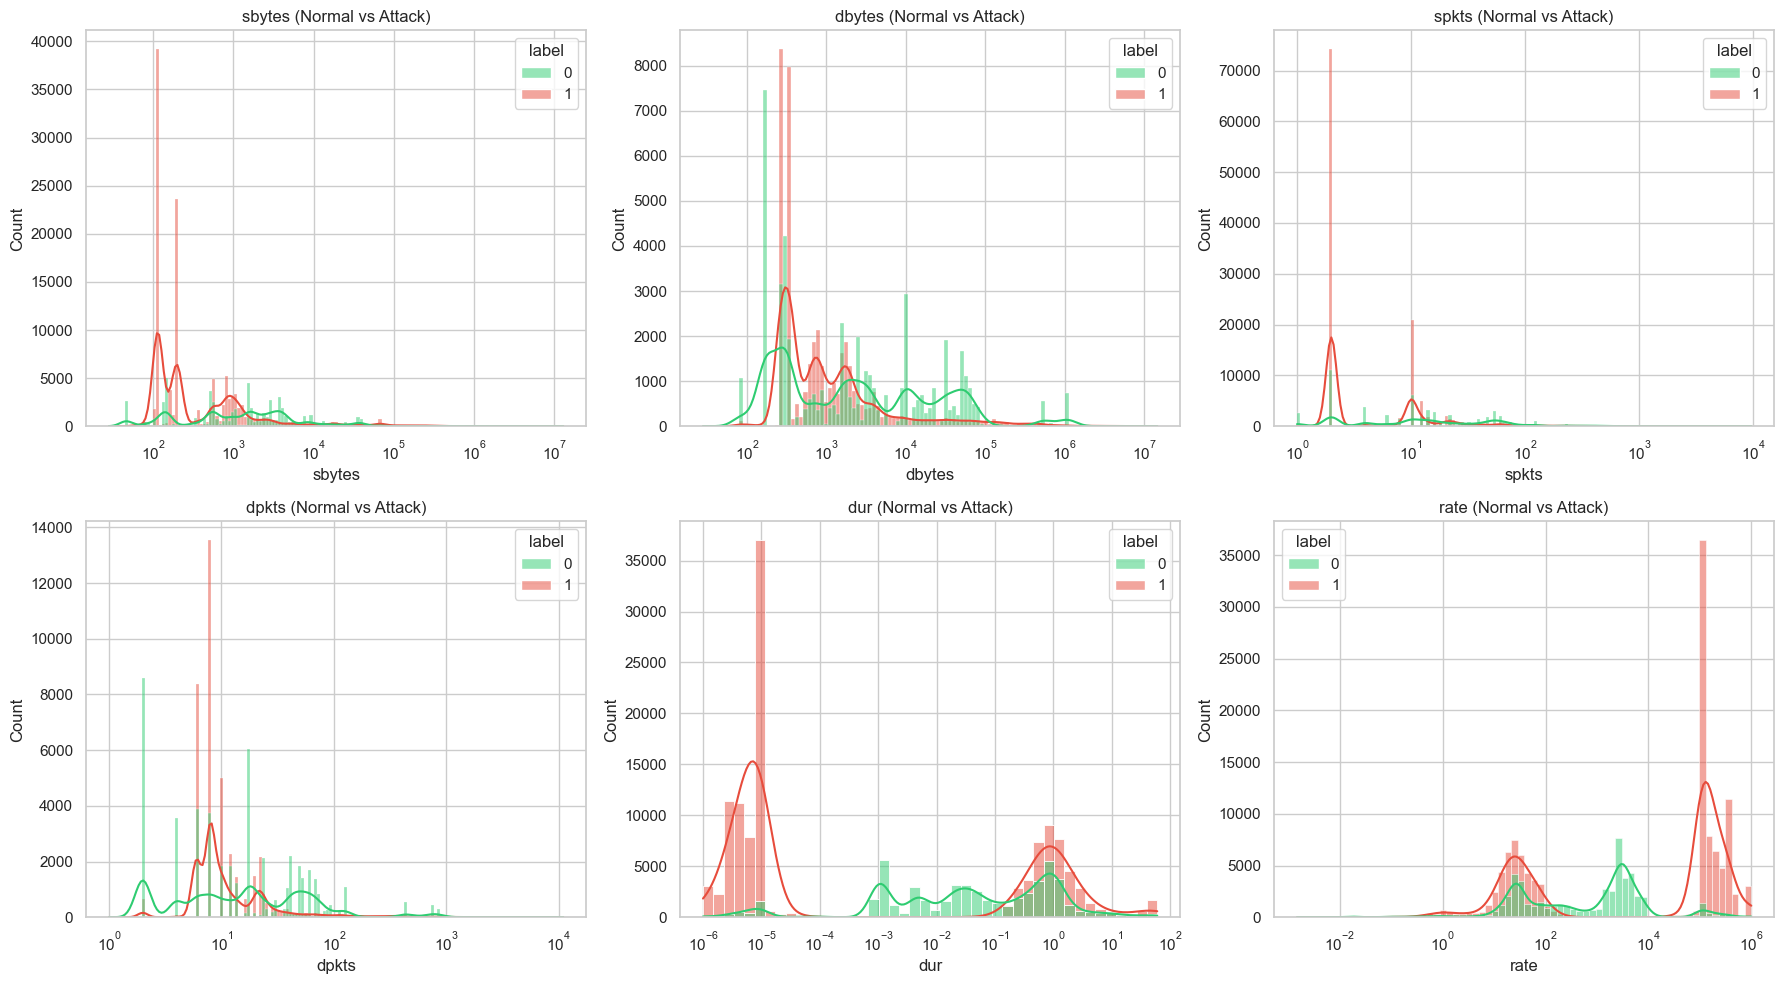

Сохранено: 03_metrics_distribution.png


In [5]:
key_metrics = ['sbytes', 'dbytes', 'spkts', 'dpkts', 'dur', 'rate']
available_metrics = [col for col in key_metrics if col in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(available_metrics[:6]):
    df_clean = df[df[col] > 0].copy()
    
    sns.histplot(data=df_clean, x=col, hue='label', 
                 kde=True, ax=axes[idx], 
                 palette=['#2ecc71', '#e74c3c'],
                 log_scale=True)
    axes[idx].set_title(f'{col} (Normal vs Attack)')

plt.tight_layout()
plt.savefig('../artifacts/visualizations/03_metrics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 03_metrics_distribution.png")

# Корреляционный анализ

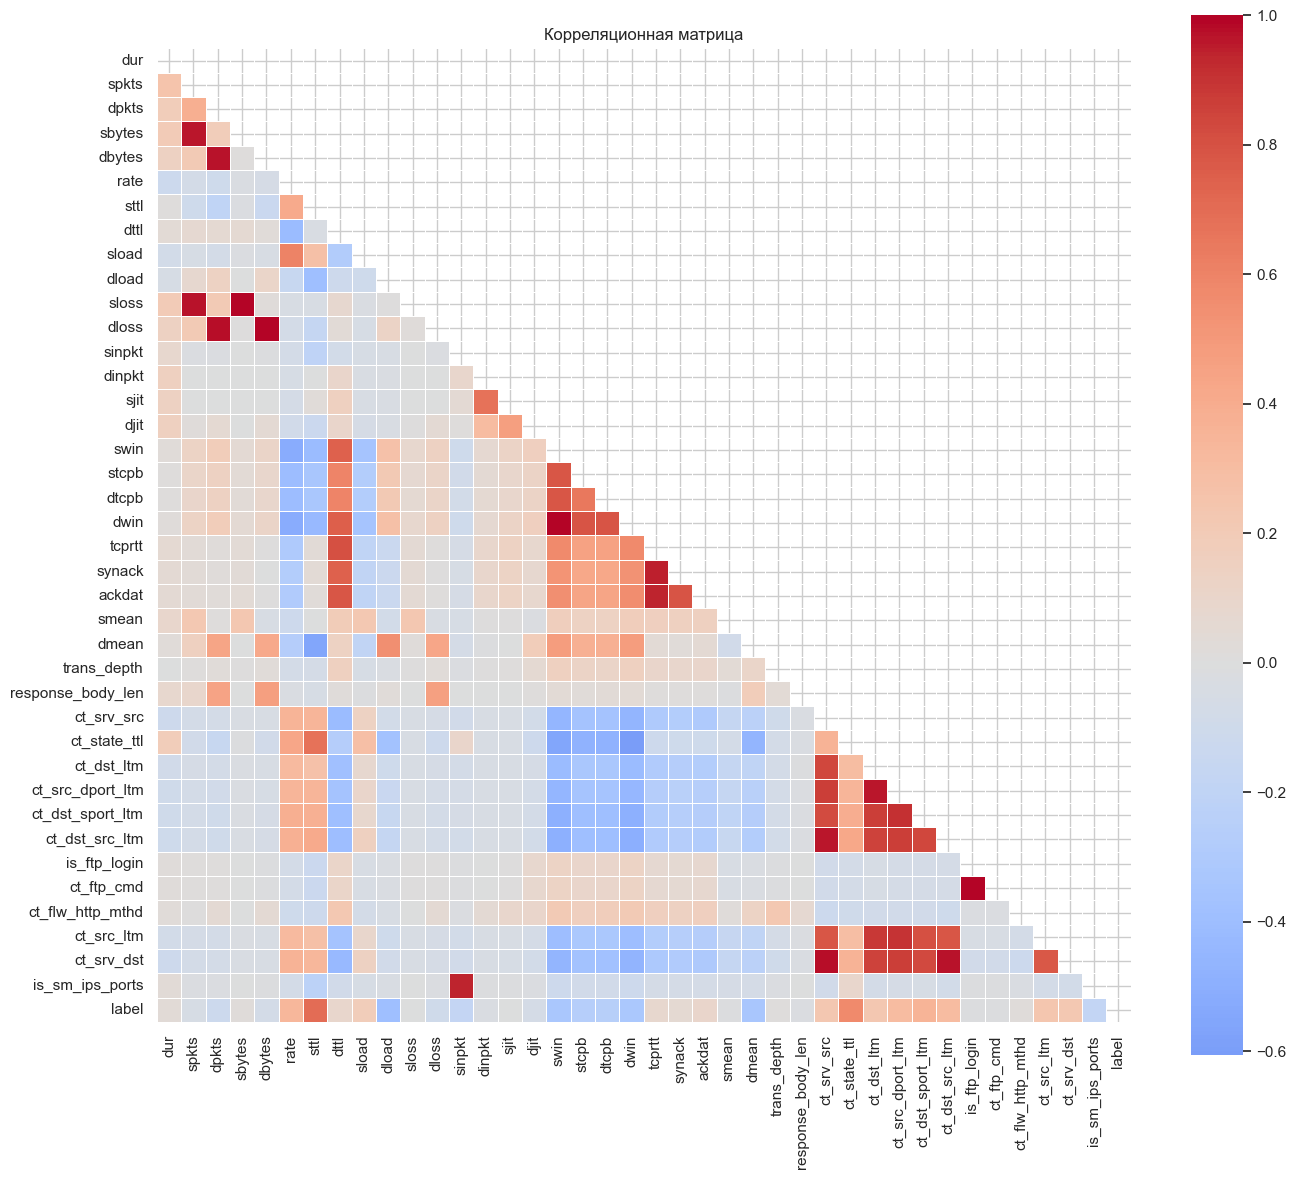

Сохранено: 04_correlation_matrix.png


C:\Users\danya\AppData\Local\Temp\ipykernel_11028\829957538.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)


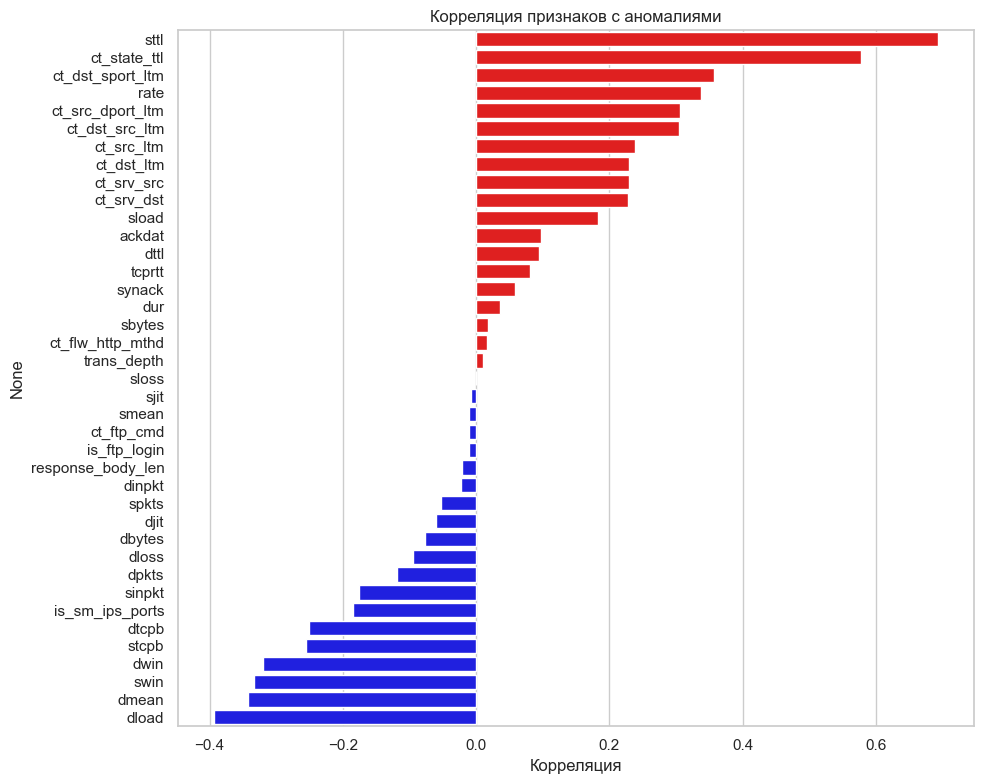

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_cols = [col for col in numeric_cols if col not in ['id']]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
            center=0, linewidths=.5, square=True)
plt.title('Корреляционная матрица')
plt.tight_layout()
plt.savefig('../artifacts/visualizations/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Сохранено: 04_correlation_matrix.png")

# Корреляция с target
if 'label' in df.columns:
    corr_with_target = corr_matrix['label'].drop('label').sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    colors = ['red' if x > 0 else 'blue' for x in corr_with_target.values]
    sns.barplot(x=corr_with_target.values, y=corr_with_target.index, palette=colors)
    plt.title('Корреляция признаков с аномалиями')
    plt.xlabel('Корреляция')
    plt.tight_layout()
    plt.show()

# Сохранение данных

In [7]:
import os
os.makedirs('../data/processed', exist_ok=True)

df_train.to_csv('../data/processed/train_raw.csv', index=False)
df_test.to_csv('../data/processed/test_raw.csv', index=False)

print(f"Сохранено:")
print(f"  - train_raw.csv ({len(df_train):,} записей)")
print(f"  - test_raw.csv ({len(df_test):,} записей)")

Сохранено:
  - train_raw.csv (175,341 записей)
  - test_raw.csv (82,332 записей)
